# 1. Import the required libraries

In [ ]:
# Standard code libraries
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from resurfemg.data_connector import file_discovery

# Custom code libraries from ReSurfEMG
from resurfemg.data_connector.config import Config
from resurfemg.data_connector.converter_functions import load_file
from resurfemg.data_connector.data_classes import EmgDataGroup, VentilatorDataGroup
from resurfemg.pipelines import ipy_widgets
from resurfemg.postprocessing import features as feat
from resurfemg.postprocessing import quality_assessment as qa

%matplotlib widget

## 2. Load the ventilator and sEMG data

### 2a With test data

In [ ]:
# Identify all recordings available for the selected patient/measurement_date

# First find the patients
config = Config()
# Then find the files for the selected patients:
base_path = config.get_directory("test_data")

emg_files = file_discovery.find_files(
    base_path=base_path, file_name_regex="emg_data_synth_*", extension_regex="*", folder_levels=None
)

vent_files = file_discovery.find_files(
    base_path=base_path, file_name_regex="vent_data_synth_*", extension_regex="*", folder_levels=None
)
folder_levels = ["files"]

INFO:resurfemg.data_connector.config:Failed to load config.json: [Errno 2] No such file or directory: 'config.json'
INFO:resurfemg.data_connector.config:Failed to load /Users/chiaramaninetti/.resurfemg/config.json: [Errno 2] No such file or directory: '/Users/chiaramaninetti/.resurfemg/config.json'
INFO:resurfemg.data_connector.config:Failed to load /etc/resurfemg/config.json: [Errno 2] No such file or directory: '/etc/resurfemg/config.json'
INFO:resurfemg.data_connector.config:Loaded config from: /Users/chiaramaninetti/Documents/M3RESP/ReSurfEMG/config.json


### 2b II - With structured patient data (faster for many datasets)

In [14]:
# # First find the patients
# config = Config()
# base_path = config.get_directory('patient_data')
# patients = file_discovery.find_folders(base_path)

# # Select the patient
# # Create a dropdown widget for patient selection
# patient_dropdown = widgets.Dropdown(
#     options=patients['destination'].tolist(),
#     description='Patient:',
#     disabled=False,
# )

# # Display the dropdown widget
# display(patient_dropdown)

In [15]:
# # Then find the files for the selected patients:
# folder_levels = ['days', 'measurement']

# emg_files = file_discovery.find_files(
#     base_path=Path(base_path).joinpath(patient_dropdown.value),
#     file_name_regex='EMG*',
#     extension_regex='poly5',
#     folder_levels=folder_levels)
# folder_levels = ['days', 'measurement']
# vent_files = file_discovery.find_files(
#     base_path=Path(base_path).joinpath(patient_dropdown.value),
#     file_name_regex='Draeger*',
#     extension_regex='poly5',
#     folder_levels=folder_levels)

# emg_files['patient'] = patient_dropdown.value
# vent_files['patient'] = patient_dropdown.value
# folder_levels.insert(0, 'patient')


### 2b II - With structured patient data

In [16]:
# # Find the files for all files that meet the ./patient/day/measurement
# # structure
# config = Config()

# base_path = config.get_directory('patient_data')
# folder_levels = ['patient','days', 'measurement']

# emg_files = file_discovery.find_files(
#     base_path=base_path,
#     file_name_regex='EMG*',
#     extension_regex='poly5',
#     folder_levels=folder_levels)
# folder_levels = ['patient','days', 'measurement']
# vent_files = file_discovery.find_files(
#     base_path=base_path,
#     file_name_regex='Draeger*',
#     extension_regex='poly5',
#     folder_levels=folder_levels)


In [17]:
# If you want to select another file:
btn_list_emg = ipy_widgets.file_select(
    emg_files, folder_levels=folder_levels, default_value_select=None, default_idx_select=[1]
)
btn_list_vent = ipy_widgets.file_select(
    vent_files, folder_levels=folder_levels, default_value_select=None, default_idx_select=[1]
)

interactive(children=(Dropdown(description='files:', index=1, options=('emg_data_synth_pocc.Poly5', 'emg_data_…

interactive(children=(Dropdown(description='files:', index=1, options=('vent_data_synth_pocc.Poly5', 'vent_dat…

In [ ]:
# Load the EMG and ventilator data recordings from the selected folders.
emg_file_chosen = str(Path(base_path).joinpath(*[str(btn.value) for btn in btn_list_emg]))
vent_file_chosen = str(Path(base_path).joinpath(*[str(btn.value) for btn in btn_list_vent]))

# Store the EMG data in a group of TimeSeries objects
print("--- Loading EMG data ---")
y_emg, _, metadata_emg = load_file(emg_file_chosen, verbose=True)
emg_timeseries = EmgDataGroup(y_emg, fs=metadata_emg["fs"], labels=metadata_emg["labels"], units=metadata_emg["units"])

# Store the ventilator data in a group of TimeSeries objects
print("\n--- Loading ventilator data ---")
y_vent, _, metadata_vent = load_file(vent_file_chosen, verbose=True)
vent_timeseries = VentilatorDataGroup(
    y_vent, fs=metadata_vent["fs"], labels=metadata_vent["labels"], units=metadata_vent["units"]
)

INFO:resurfemg.data_connector.converter_functions:Detected .poly5
INFO:resurfemg.data_connector.converter_functions:Loading .Poly5 ...
INFO:resurfemg.data_connector.tmsisdk_lite:Reading file /Users/chiaramaninetti/Documents/M3RESP/ReSurfEMG/test_data/emg_data_synth_quiet_breathing.Poly5
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of samples:  860160 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of channels:  2 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Sample rate: 2048 Hz
INFO:resurfemg.data_connector.tmsisdk_lite:Done reading data.
INFO:resurfemg.data_connector.converter_functions:Loaded .Poly5, extracting data ...
INFO:resurfemg.data_connector.converter_functions:Loading data completed


--- Loading EMG data ---


INFO:resurfemg.data_connector.converter_functions:Selected channels: [0, 1]
INFO:resurfemg.data_connector.converter_functions:Detected .poly5
INFO:resurfemg.data_connector.converter_functions:Loading .Poly5 ...
INFO:resurfemg.data_connector.tmsisdk_lite:Reading file /Users/chiaramaninetti/Documents/M3RESP/ReSurfEMG/test_data/vent_data_synth_quiet_breathing.Poly5
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of samples:  42000 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of channels:  3 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Sample rate: 100 Hz
INFO:resurfemg.data_connector.tmsisdk_lite:Done reading data.
INFO:resurfemg.data_connector.converter_functions:Loaded .Poly5, extracting data ...
INFO:resurfemg.data_connector.converter_functions:Loading data completed
INFO:resurfemg.data_connector.converter_functions:Selected channels: [0, 1, 2]



--- Loading ventilator data ---


# 3. Pre-process the data

In [19]:
# Filter
emg_timeseries.filter_emg()

In [20]:
# ECG removal
# ECG peak detection:
emg_timeseries.get_ecg_peaks(overwrite=True)
# OR Set the peaks manually:
# emg_timeseries.set_peaks(ecg_peak_idxs, y_ecg, 'ecg', overwrite=True)


# Through gating
emg_timeseries.gating()

# # Through wavelet denoising
# emg_timeseries.wavelet_denoising()
# # emg_timeseries.wavelet_denoising(n=8, fixed_threshold=8.0)

In [21]:
# Calculate the envelope of the signal
emg_timeseries.envelope()
# emg_timeseries.envelope(ci_alpha=0.05)
# emg_timeseries.envelope(env_type='arv')
# emg_timeseries.envelope(env_type='arv', ci_alpha=0.05)

In [22]:
# Calculate the baseline for the EMG envelopes and p_vent
emg_timeseries.baseline()
vent_timeseries.baseline(channel_idxs=[0], signal_io=("raw", "baseline"))

(0.0, 10.0)

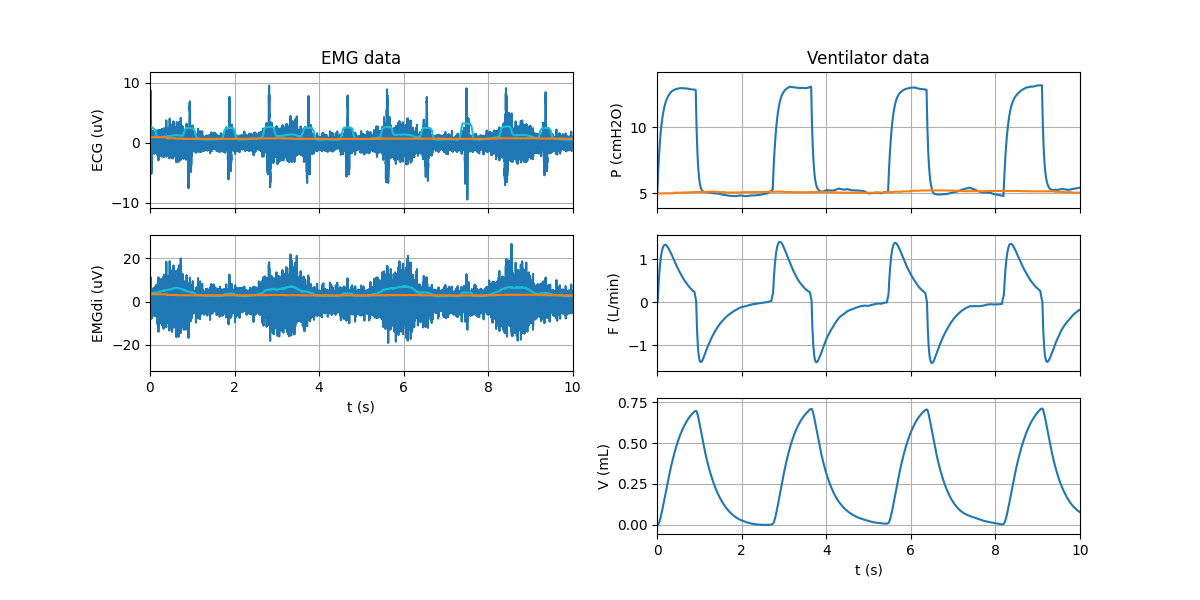

In [23]:
# Plot the raw data with the envelope
# EMG data
n_rows = max([len(emg_timeseries.channels), len(vent_timeseries.channels)])
fig, axis = plt.subplots(nrows=n_rows, ncols=2, figsize=(12, n_rows * 2), sharex=True)
axes_emg = axis[: len(emg_timeseries.channels), 0]
colors = ["tab:cyan", "tab:orange"]
emg_timeseries.plot_full(axes=axes_emg, signal_io=("clean",), baseline_bool=False)
emg_timeseries.plot_full(axes=axes_emg, signal_io=("env",), colors=colors)

axes_emg[0].set_title("EMG data")
axes_emg[-1].set_xlabel("t (s)")

# Ventilator data data
axes_vent = axis[:, 1]
vent_timeseries.plot_full(axes=axes_vent)
axes_vent[0].set_title("Ventilator data")
axes_vent[-1].set_xlabel("t (s)")

if n_rows > len(emg_timeseries.channels):
    for ax_idx in range(len(emg_timeseries.channels), n_rows):
        axis[ax_idx, 0].axis("off")
    axis[len(emg_timeseries.channels) - 1, 0].tick_params(axis="x", which="both", labelbottom=True)

axes_emg[-1].set_xlim([0, 10])

# 3. Identify supported breaths in p_vent

In [24]:
# Set p_vent_idx if it is not already set
if vent_timeseries.p_vent_idx is None:
    vent_timeseries.p_vent_idx = 0

# Set v_vent_idx if it is not already set
if vent_timeseries.v_vent_idx is None:
    vent_timeseries.v_vent_idx = 2

In [25]:
# Find supported breath pressures
p_vent = vent_timeseries[vent_timeseries.p_vent_idx]
v_vent = vent_timeseries[vent_timeseries.v_vent_idx]
vent_timeseries.find_tidal_volume_peaks()
p_vent.peaks["ventilator_breaths"].detect_on_offset(
    baseline=p_vent["baseline"],
)


# 4. Identify all sEMG breaths

Two strategies can be employed: 
- a. detect any EMG peak that can possibly a breath and eliminate implausible breaths based on the quality criteria;
- b. detect only higher EMG peaks by using a higher threshold for detection.

The former is used below. The latter can be implemented by setting additional parameters for the detect_emg_breaths method.

In [26]:
# Find sEAdi peaks in one channel (sEAdi)
emg_di = emg_timeseries["EMGdi"]
emg_di.detect_emg_breaths(peak_set_name="breaths")
# emg_di.detect_emg_breaths(peak_set_name='breaths', prominence_factor=1.5)

# Similar to above for Pocc and ventilator breaths:
emg_di.peaks["breaths"].detect_on_offset(baseline=emg_di["baseline"])

# 5. Calculate features

In [27]:
# Respiratory rates based on ventilator data
tv_idxs = v_vent.peaks["ventilator_breaths"]["peak_idx"]
rr_vent, _ = feat.respiratory_rate(tv_idxs, metadata_vent["fs"])

rr_vent, _ = feat.respiratory_rate(v_vent.peaks["ventilator_breaths"]["peak_idx"], v_vent.param["fs"])
v_vent.param["rr"] = rr_vent
p_vent.param["rr"] = rr_vent
print(f"The detected respiratory rate in the ventilator data is: {round(rr_vent, 1)} /min")

# Respiratory rates based on EMG data
emg_di_idxs = emg_di.peaks["breaths"]["peak_idx"]
rr_emg, _ = feat.respiratory_rate(emg_di_idxs, metadata_emg["fs"])
emg_di.param["rr"] = rr_emg
print(f"The detected respiratory rate in the sEAdi data is: {round(rr_emg, 1)} /min")

The detected respiratory rate in the ventilator data is: 22.0 /min
The detected respiratory rate in the sEAdi data is: 22.0 /min


In [ ]:
# EMG amplitudes
emg_di_pocc_idxs = emg_di.peaks["breaths"]["peak_idx"]
seadi_amplitudes = feat.amplitude(
    signal=np.asarray(emg_di["env"]),
    peak_idxs=emg_di_pocc_idxs,
    baseline=np.asarray(emg_di["baseline"]),
)
emg_di.peaks["breaths"].peak_df["amplitude"] = seadi_amplitudes

In [29]:
# Calculate ETPdi
emg_di.calculate_time_products(peak_set_name="breaths", parameter_name="ETPdi")

# 6. Test sEMG quality

In [30]:
# Test EMG quality on an individual peak basis. This includes the following
# tests:
# - interpeak_distance: EMG interpeak time as compared to ECG interbeat time
# - snr: pseudo signal-to-noise ratio
# - aub: area under the baseline relative to total ETP
# - curve_fit: deviation of the bell curve fit relative to total ETP
#
# Relative ETP and AUB tested during a second stage, including only peaks that
# passed the first stage.

parameter_names = {"time_product": "ETPdi"}
emg_di.test_emg_quality(
    skip_tests=["relative_etp", "relative_aub"], peak_set_name="breaths", parameter_names=parameter_names, verbose=False
)

In [31]:
# Remove peaks that did not pass the quality tests
emg_di.peaks["breaths"].sanitize()

In [32]:
# Test EMG quality for relative_etp and relative_aub
parameter_names = {"time_product": "ETPdi"}
emg_di.test_emg_quality(skip_tests=[], peak_set_name="breaths", parameter_names=parameter_names, verbose=False)

(0.0, 10.0)

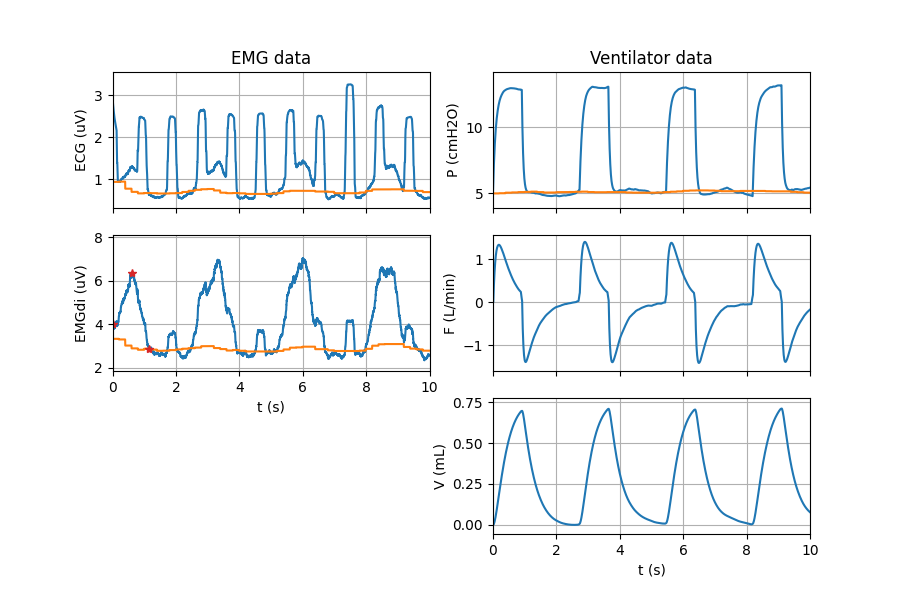

In [33]:
# Plot identified peaks
fig, axis = plt.subplots(nrows=n_rows, ncols=2, figsize=(n_rows * 3, 6), sharex=True)
axes_emg = axis[: len(emg_timeseries.channels), 0]

colors = ["tab:cyan", "tab:orange"]
# emg_timeseries.run(
#     'plot_full', axes=axes_emg, signal_io=('clean',), baseline_bool=False)
emg_timeseries.plot_full(axes=axes_emg, signal_io=("env",))
emg_timeseries[1].plot_markers(peak_set_name="breaths", axes=axes_emg[1], valid_only=True)

axes_emg[0].set_title("EMG data")
axes_emg[-1].set_xlabel("t (s)")

# Ventilator data data
axes_vent = axis[:, 1]
vent_timeseries.plot_full(axes=axes_vent)
axes_vent[0].set_title("Ventilator data")
axes_vent[-1].set_xlabel("t (s)")


if n_rows > len(emg_timeseries.channels):
    for ax_idx in range(len(emg_timeseries.channels), n_rows):
        axis[ax_idx, 0].axis("off")
    axis[len(emg_timeseries.channels) - 1, 0].tick_params(axis="x", which="both", labelbottom=True)

axes_vent[-1].set_xlim([0, 10])

# 5. Link EMG breaths to closest Ventilator breaths

In [34]:
# Find the EMG peaks with the peak timing closest to the Pocc timings, and
# link ventilator Pocc peaks to EMG breaths
t_peaks_vent = p_vent.peaks["ventilator_breaths"]["peak_idx"] / p_vent.param["fs"]

emg_di.link_peak_set(
    peak_set_name="breaths",
    t_reference_peaks=t_peaks_vent,
    linked_peak_set_name="linked_breaths",
)

In [35]:
# Eliminate linked peaks that do not fall within the set window around the
# tidal volume peak
cutoff = {}
cutoff["fraction_emg_breaths"] = 0.1
cutoff["delta_min"] = -0.5
cutoff["delta_max"] = 30 / v_vent.param["rr"]
emg_di.test_linked_peak_sets("linked_breaths", v_vent, "ventilator_breaths", cutoff=cutoff, verbose=False)

In [36]:
emg_di.peaks["linked_breaths"].sanitize()

In [37]:
# Create a new peak set for the linked peaks in the ventilator timeseries
t_emg_breaths = emg_di.peaks["linked_breaths"]["peak_idx"] / emg_di.param["fs"]

v_vent.link_peak_set(
    peak_set_name="ventilator_breaths",
    t_reference_peaks=t_emg_breaths,
    linked_peak_set_name="linked_breaths",
)


In [ ]:
# Test general signal characteristics
emg_di_idxs = emg_di.peaks["linked_breaths"]["peak_idx"]

fraction_emg_breaths, _ = qa.evaluate_respiratory_rates(
    emg_breath_idxs=emg_di_idxs, t_emg=float(np.max(emg_di.t_data)), rr_vent=rr_vent
)
print(f"The fraction detected EMG breaths is: {100 * fraction_emg_breaths:0.2f} %")

The fraction detected EMG breaths is: 100.10 %


## 6 Plot a subset of identified ventilator and sEMG peaks

In [39]:
# Create new peak sets with the first 4 breaths
t_first_emg_peaks = emg_di.peaks["linked_breaths"].peak_df.loc[:3, "peak_idx"].to_numpy() / metadata_emg["fs"]
emg_di.link_peak_set(
    peak_set_name="linked_breaths",
    t_reference_peaks=t_first_emg_peaks,
    linked_peak_set_name="first_breaths",
)

p_vent.link_peak_set(
    peak_set_name="ventilator_breaths",
    t_reference_peaks=t_first_emg_peaks,
    linked_peak_set_name="first_breaths",
)
v_vent.link_peak_set(
    peak_set_name="ventilator_breaths",
    t_reference_peaks=t_first_emg_peaks,
    linked_peak_set_name="first_breaths",
)


(0.0, 10.0)

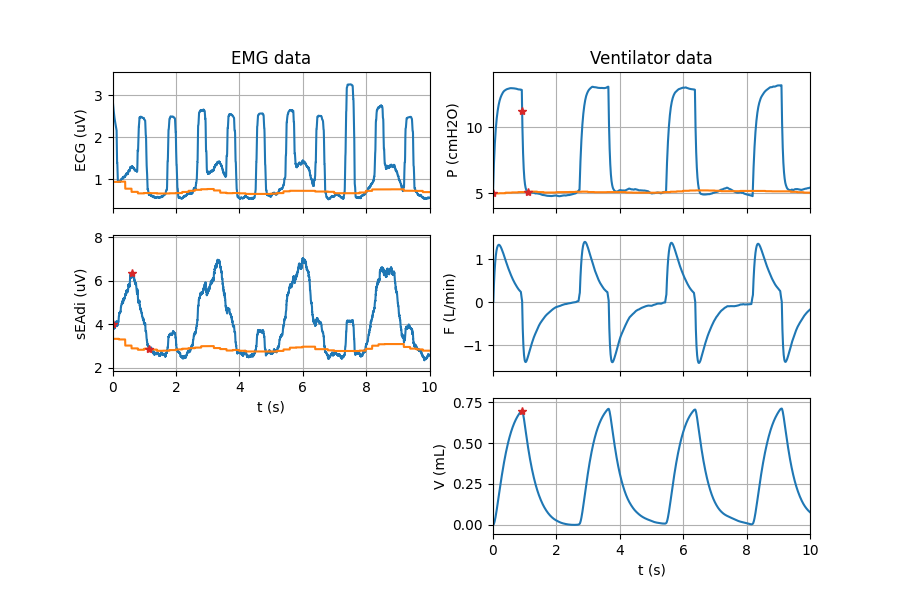

In [40]:
# Plot the identified Pocc peaks in p_vent and sEAdi
fig, axis = plt.subplots(nrows=n_rows, ncols=2, figsize=(n_rows * 3, 6), sharex=True)
axes_emg = axis[: len(emg_timeseries.channels), 0]
colors = ["tab:cyan", "tab:orange", "tab:red"]
emg_timeseries.plot_full(axes=axes_emg, signal_io=("env",))
emg_di.plot_markers(peak_set_name="first_breaths", axes=axes_emg[1])


axes_emg[1].set_ylabel("sEAdi (uV)")
axes_emg[0].set_title("EMG data")
axes_emg[-1].set_xlabel("t (s)")

axes_vent = axis[:, 1]
vent_timeseries.plot_full(axes=axes_vent)
p_vent.plot_markers(peak_set_name="first_breaths", axes=axes_vent[0])
v_vent.plot_markers(peak_set_name="first_breaths", axes=axes_vent[2])

axes_vent[0].set_title("Ventilator data")
axes_vent[-1].set_xlabel("t (s)")

if n_rows > len(emg_timeseries.channels):
    for ax_idx in range(len(emg_timeseries.channels), n_rows):
        axis[ax_idx, 0].axis("off")
    axis[len(emg_timeseries.channels) - 1, 0].tick_params(axis="x", which="both", labelbottom=True)


# Let's zoom in on the subset of peaks:
axes_vent[-1].set_xlim([0, 10])

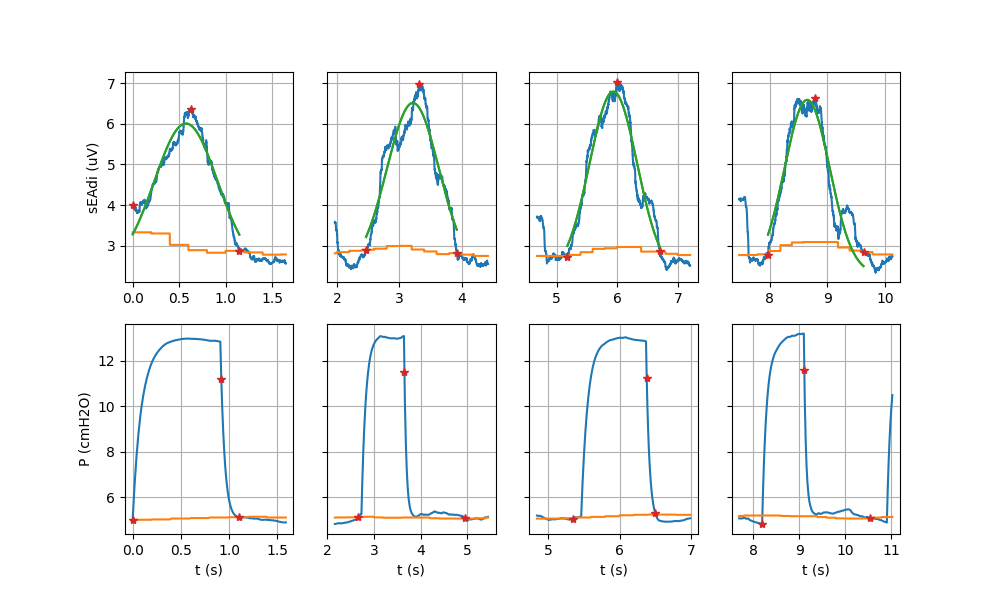

In [41]:
# Plot the individual peaks bell-fit

n_peaks = len(emg_di.peaks["first_breaths"].peak_df["start_idx"])
fig, axis = plt.subplots(nrows=2, ncols=n_peaks, figsize=(10, 6), sharey="row")

axes_emg = axis[0, :]
colors = ["tab:cyan", "tab:orange", "tab:red"]
emg_di.plot_peaks(axes=axes_emg, peak_set_name="first_breaths")
emg_di.plot_markers(axes=axes_emg, peak_set_name="first_breaths")
emg_di.plot_curve_fits(axes=axes_emg, peak_set_name="first_breaths")
axes_emg[0].set_ylabel("sEAdi (uV)")

axes_vent = axis[1, :]
p_vent.plot_peaks(axes=axes_vent, peak_set_name="first_breaths")
p_vent.plot_markers(axes=axes_vent, peak_set_name="first_breaths")

for axis in axes_vent:
    axis.set_xlabel("t (s)")

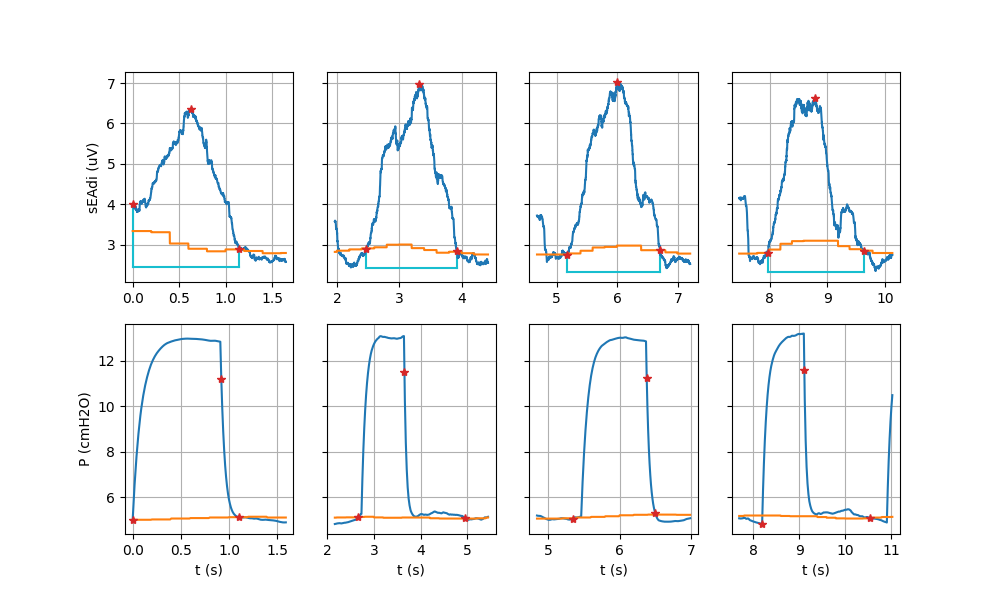

In [42]:
# Plot the individual peaks area under the baseline
n_peaks = len(emg_di.peaks["first_breaths"]["start_idx"])
fig, axis = plt.subplots(nrows=2, ncols=n_peaks, figsize=(10, 6), sharey="row")

axes_emg = axis[0, :]
emg_di.plot_aub(axes=axes_emg, signal_io=("env",), peak_set_name="first_breaths")
colors = ["tab:cyan", "tab:orange", "tab:red"]
emg_di.plot_peaks(axes=axes_emg, peak_set_name="first_breaths")
emg_di.plot_markers(axes=axes_emg, peak_set_name="first_breaths")
axes_emg[0].set_ylabel("sEAdi (uV)")

axes_vent = axis[1, :]
p_vent.plot_peaks(axes=axes_vent, peak_set_name="first_breaths")
p_vent.plot_markers(axes=axes_vent, peak_set_name="first_breaths")

for axis in axes_vent:
    axis.set_xlabel("t (s)")